# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Employee Attrition Dataset](https://www.kaggle.com/datasets/srisyra02/employee-attrition-and-hr-analytics)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

/kaggle/input/datasets/srisyra02/employee-attrition-and-hr-analytics/employee_attrition_analysis_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('employee_attrition_analysis_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,4,2,1,3,4,14,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,9,1,2,1,1,6,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,14,8,3,2,1,77,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,8,2,3,5,4,49,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,10,1,2,5,1,64,No,3,33,0,4,1,3,44,3,No


## last Five row

In [4]:
df.tail()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
1495,1496,43,Male,Married,Finance,Analyst,1,19663,99,3,14,7,1,4,1,9,Yes,5,52,10,3,4,1,44,4,No
1496,1497,22,Male,Married,IT,Assistant,5,4861,22,8,14,9,1,4,3,33,Yes,4,46,17,2,1,3,7,4,No
1497,1498,24,Female,Divorced,Marketing,Assistant,2,15197,77,2,4,0,1,5,4,33,Yes,1,39,14,2,1,4,40,3,No
1498,1499,44,Female,Married,Sales,Manager,3,18897,62,24,12,1,4,5,2,82,Yes,7,59,19,1,2,1,17,1,No
1499,1500,51,Female,Married,Marketing,Assistant,1,12499,80,2,11,4,1,4,1,65,Yes,2,44,5,1,1,4,19,2,No


## Shape of our dataset

In [5]:
df.shape

(1500, 26)

## List out all columns

In [6]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Employee_ID                       int64
Age                               int64
Gender                           object
Marital_Status                   object
Department                       object
Job_Role                         object
Job_Level                         int64
Monthly_Income                    int64
Hourly_Rate                       int64
Years_at_Company                  int64
Years_in_Current_Role             int64
Years_Since_Last_Promotion        int64
Work_Life_Balance                 int64
Job_Satisfaction                  int64
Performance_Rating                int64
Training_Hours_Last_Year          int64
Overtime                         object
Project_Count                     int64
Average_Hours_Worked_Per_Week     int64
Absenteeism                       int64
Work_Environment_Satisfaction     int64
Relationship_with_Manager         int64
Job_Involvement                   int64
Distance_From_Home                int64
Number_of_Companies_Worked        int64


## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1500 non-null   int64 
 1   Age                            1500 non-null   int64 
 2   Gender                         1500 non-null   object
 3   Marital_Status                 1500 non-null   object
 4   Department                     1500 non-null   object
 5   Job_Role                       1500 non-null   object
 6   Job_Level                      1500 non-null   int64 
 7   Monthly_Income                 1500 non-null   int64 
 8   Hourly_Rate                    1500 non-null   int64 
 9   Years_at_Company               1500 non-null   int64 
 10  Years_in_Current_Role          1500 non-null   int64 
 11  Years_Since_Last_Promotion     1500 non-null   int64 
 12  Work_Life_Balance              1500 non-null   int64 
 13  Job

## Check Null Value

In [9]:
df.isnull().sum()

Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,39.789333,3.052667,11605.540000,57.478667,14.878667,7.582000,4.425333,2.504000,3.139333,2.527333,50.318667,4.888000,44.410667,9.634000,2.47400,2.493333,2.488000,24.262667,2.468667
std,433.157015,11.709670,1.396851,4881.361846,24.943730,8.263179,4.007408,3.001516,1.107611,1.451892,1.128761,27.988748,2.545802,8.775270,6.061177,1.11392,1.103978,1.100301,14.001251,1.101738
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000
25%,375.750000,29.000000,2.000000,7586.500000,35.000000,8.000000,4.000000,2.000000,2.000000,2.000000,1.750000,26.000000,3.000000,37.000000,4.000000,1.75000,2.000000,2.000000,12.000000,1.750000
50%,750.500000,41.000000,3.000000,11514.000000,58.000000,15.000000,8.000000,4.000000,3.000000,3.000000,3.000000,51.000000,5.000000,44.000000,9.000000,2.00000,2.000000,3.000000,23.000000,2.000000
75%,1125.250000,50.000000,4.000000,15855.000000,79.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.250000,7.000000,52.000000,15.000000,3.00000,3.000000,3.000000,36.000000,3.000000
max,1500.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.00000,4.000000,4.000000,49.000000,4.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

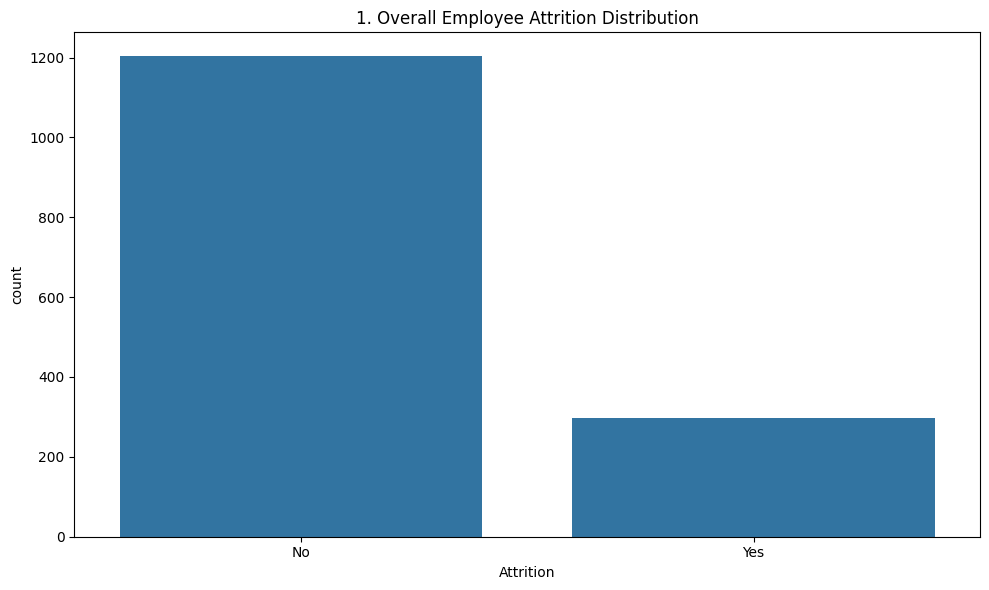

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Attrition')
plt.title(f'{plot_no}. Overall Employee Attrition Distribution')
show_fig()
plot_no += 1

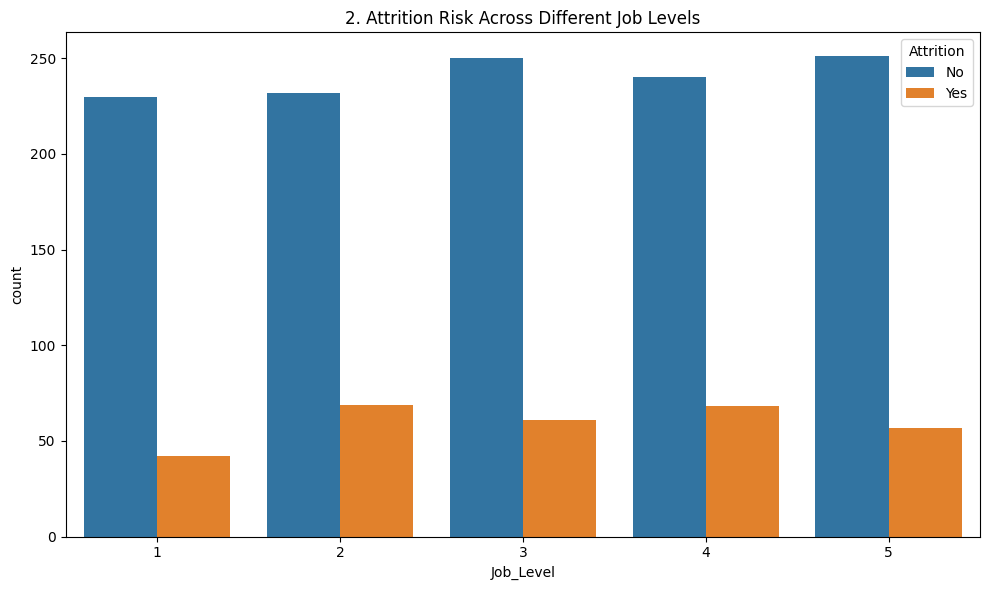

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Job_Level', hue='Attrition')
plt.title(f'{plot_no}. Attrition Risk Across Different Job Levels')
show_fig()
plot_no += 1

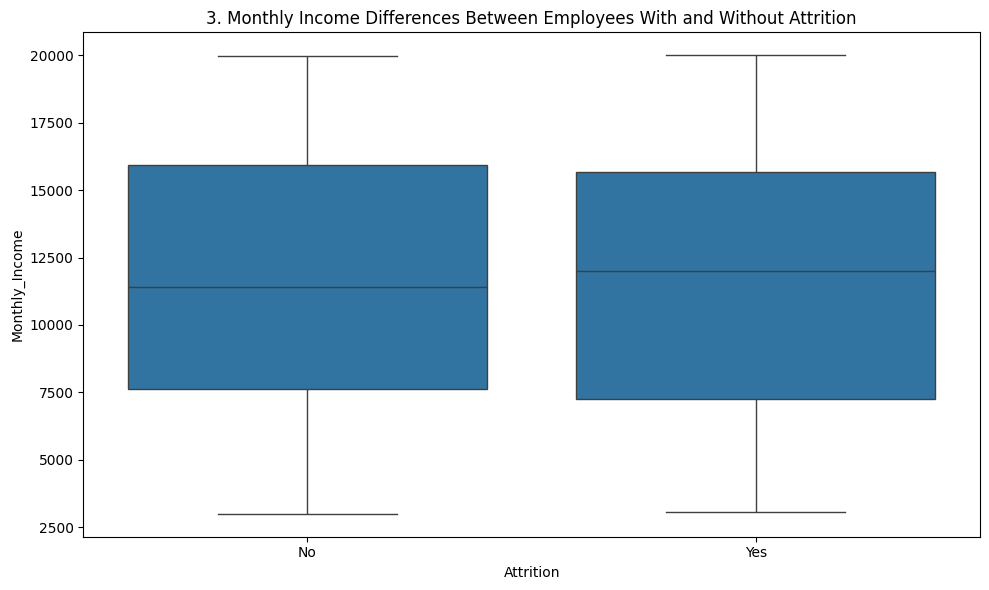

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Monthly_Income')
plt.title(f'{plot_no}. Monthly Income Differences Between Employees With and Without Attrition')
show_fig()
plot_no += 1

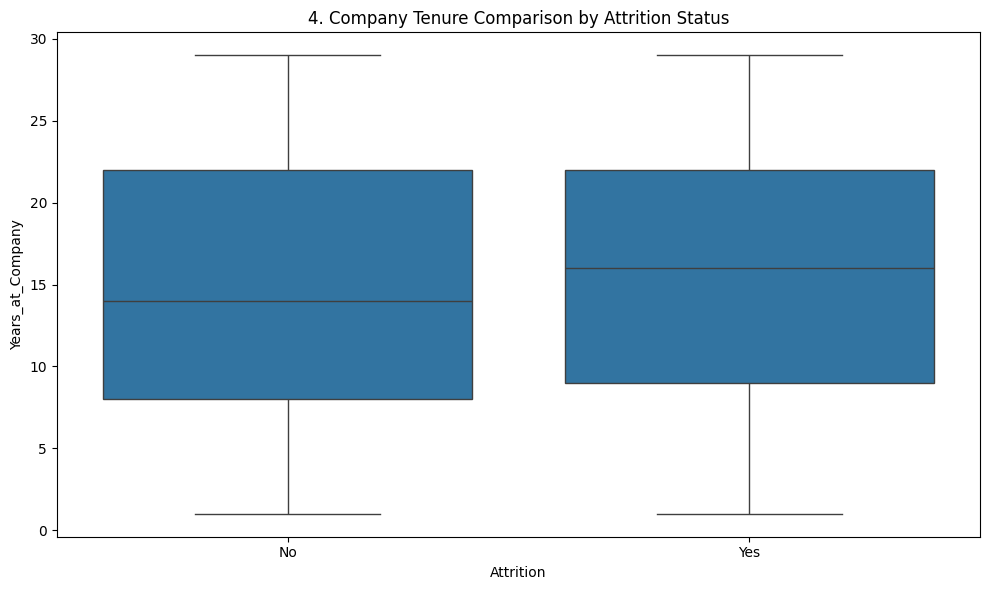

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Years_at_Company')
plt.title(f'{plot_no}. Company Tenure Comparison by Attrition Status')
show_fig()
plot_no += 1

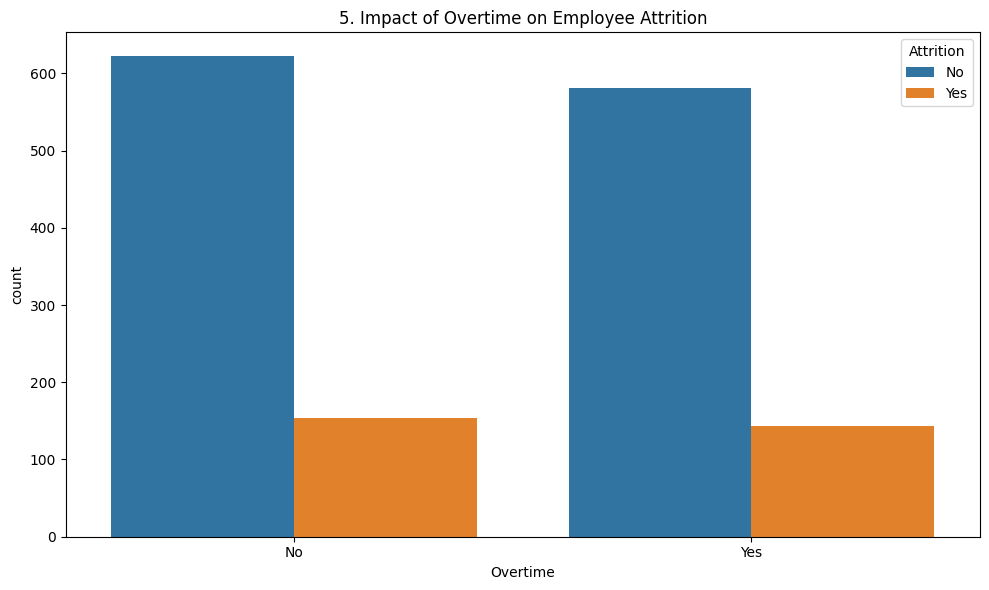

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Overtime', hue='Attrition')
plt.title(f'{plot_no}. Impact of Overtime on Employee Attrition')
show_fig()
plot_no += 1

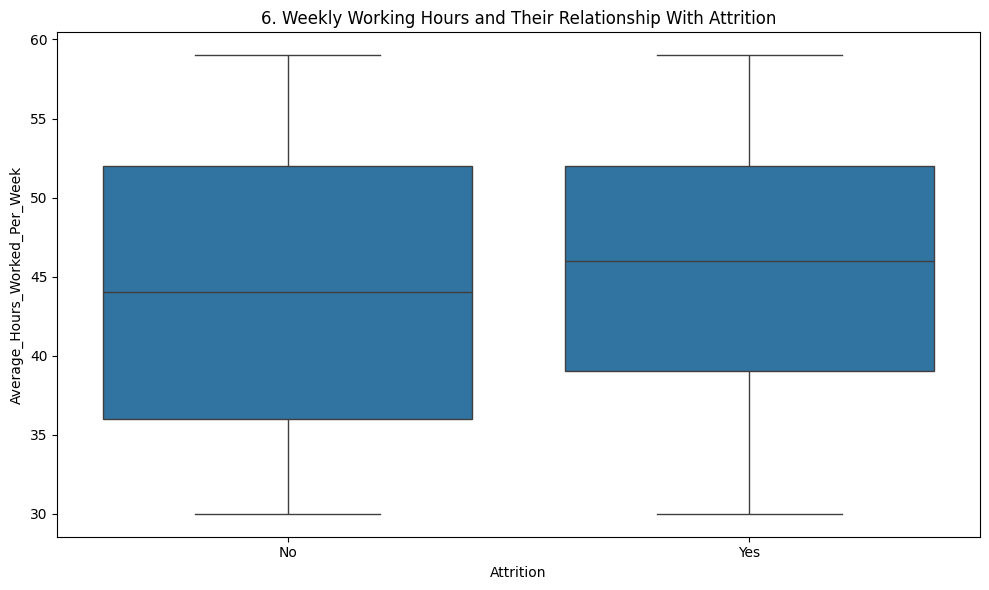

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Average_Hours_Worked_Per_Week')
plt.title(f'{plot_no}. Weekly Working Hours and Their Relationship With Attrition')
show_fig()
plot_no += 1

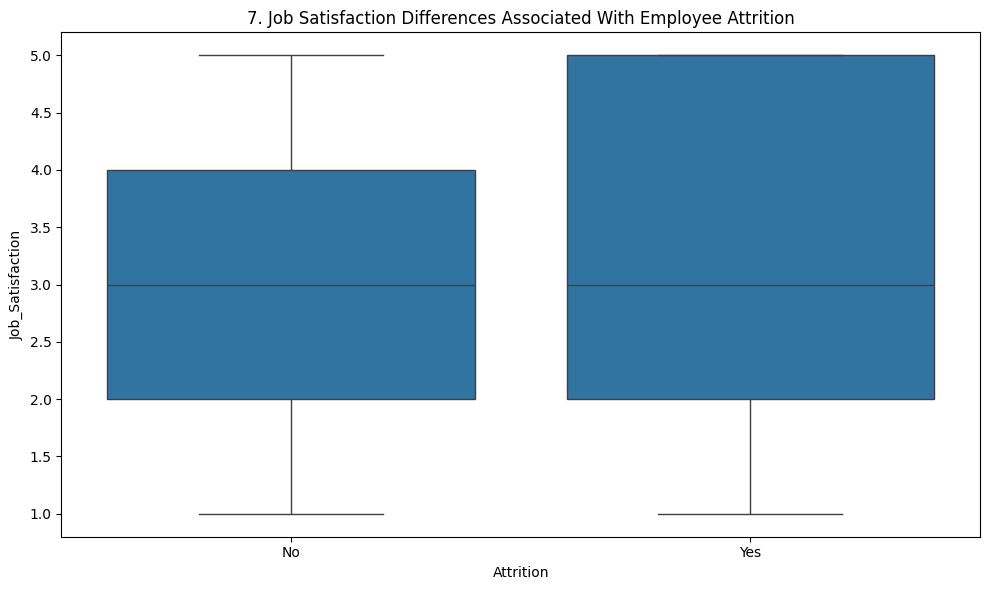

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Job_Satisfaction')
plt.title(f'{plot_no}. Job Satisfaction Differences Associated With Employee Attrition')
show_fig()
plot_no += 1

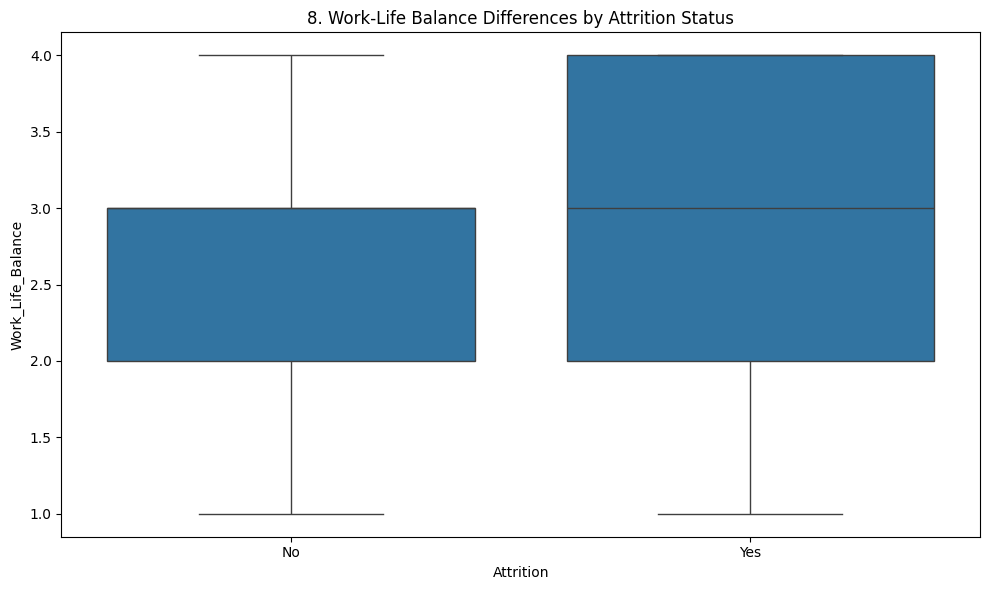

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Work_Life_Balance')
plt.title(f'{plot_no}. Work-Life Balance Differences by Attrition Status')
show_fig()
plot_no += 1

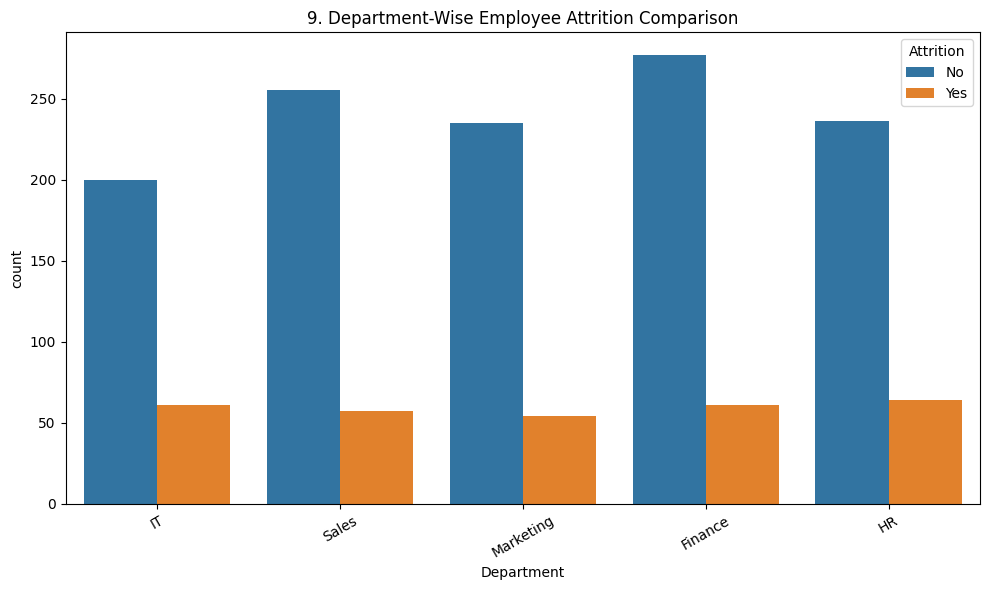

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title(f'{plot_no}. Department-Wise Employee Attrition Comparison')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

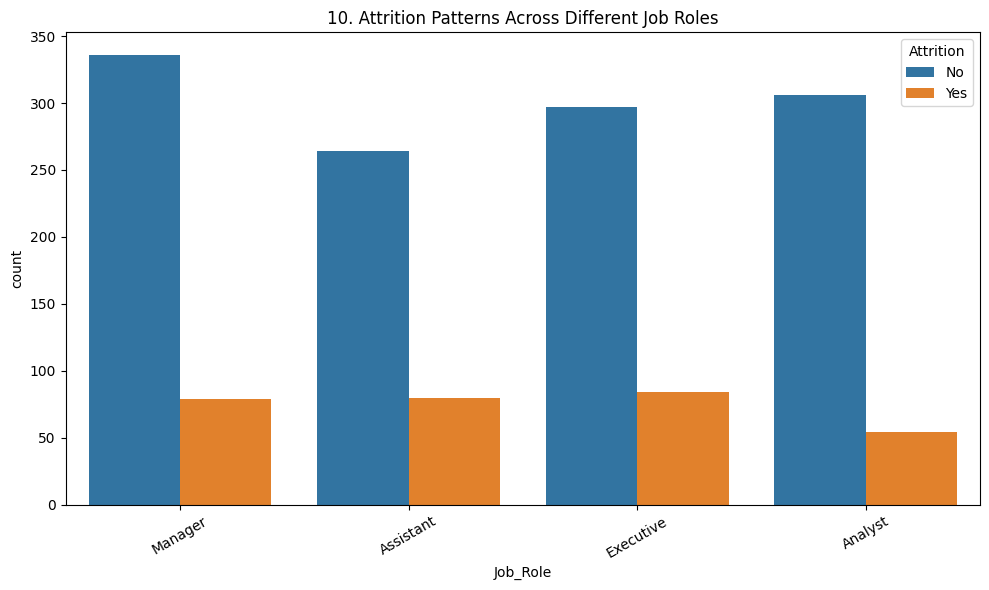

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Job_Role', hue='Attrition')
plt.title(f'{plot_no}. Attrition Patterns Across Different Job Roles')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

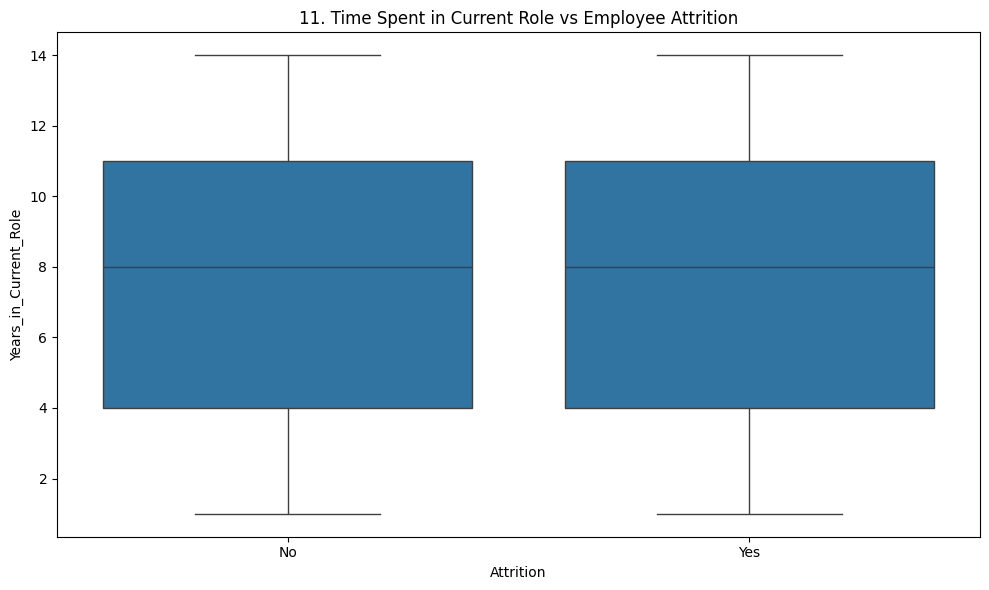

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Years_in_Current_Role')
plt.title(f'{plot_no}. Time Spent in Current Role vs Employee Attrition')
show_fig()
plot_no += 1

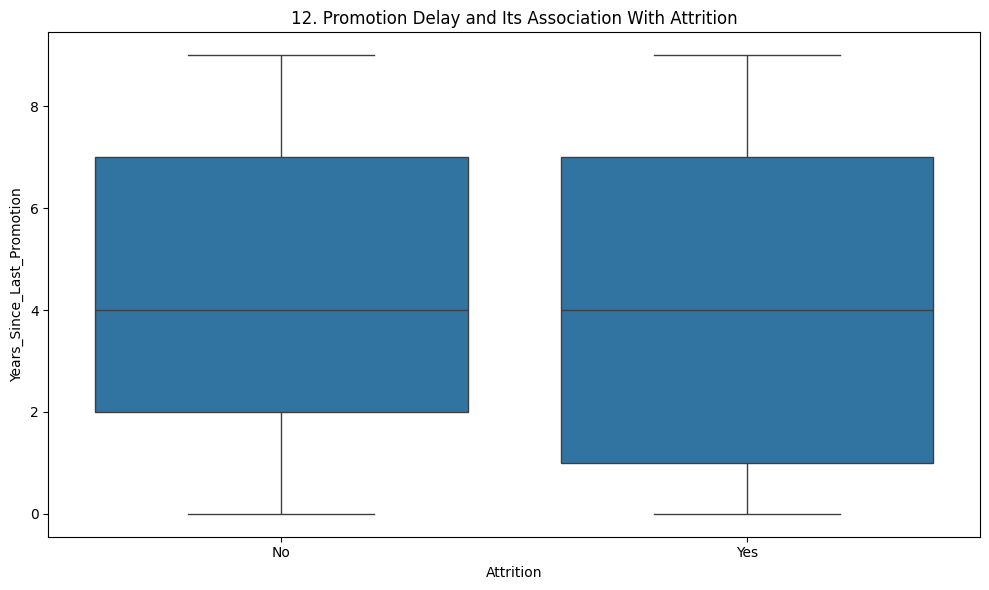

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Years_Since_Last_Promotion')
plt.title(f'{plot_no}. Promotion Delay and Its Association With Attrition')
show_fig()
plot_no += 1

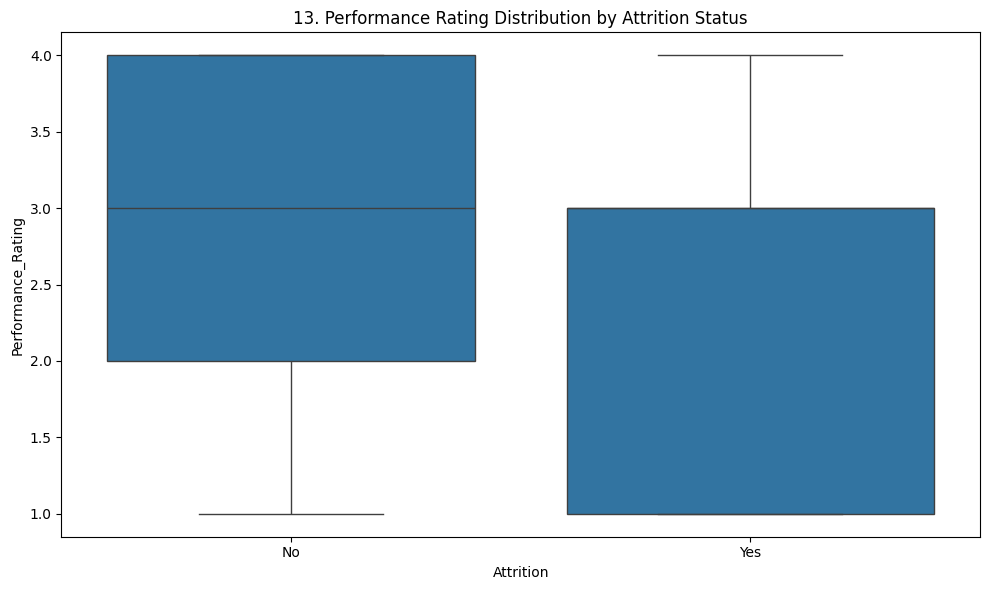

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Performance_Rating')
plt.title(f'{plot_no}. Performance Rating Distribution by Attrition Status')
show_fig()
plot_no += 1

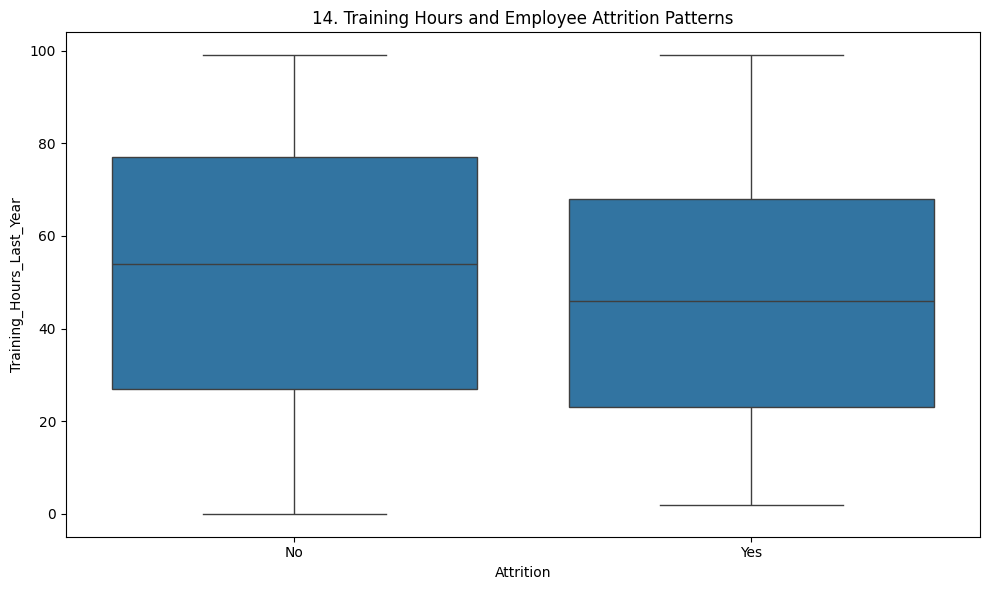

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Training_Hours_Last_Year')
plt.title(f'{plot_no}. Training Hours and Employee Attrition Patterns')
show_fig()
plot_no += 1

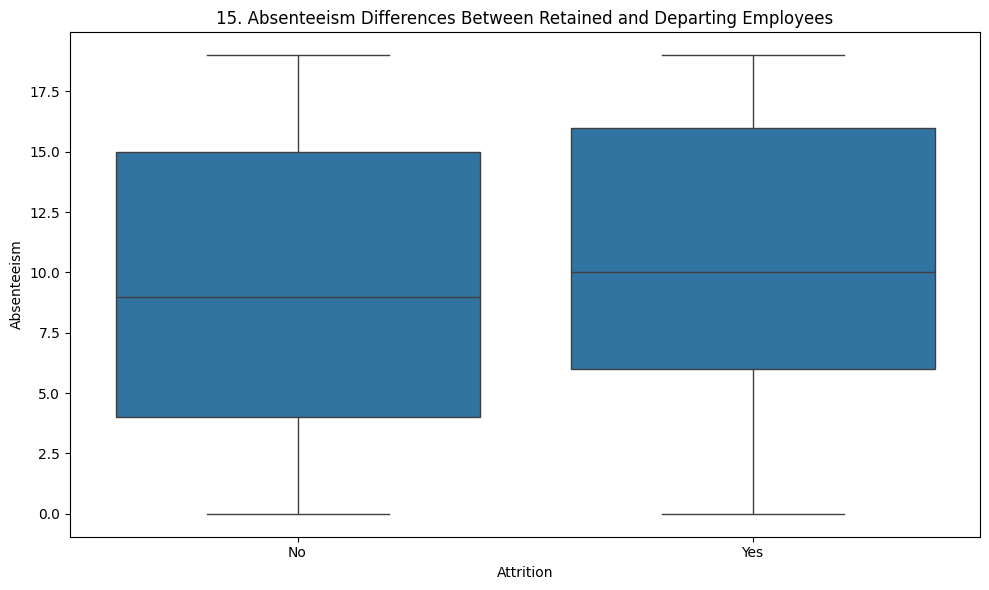

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Absenteeism')
plt.title(f'{plot_no}. Absenteeism Differences Between Retained and Departing Employees')
show_fig()
plot_no += 1

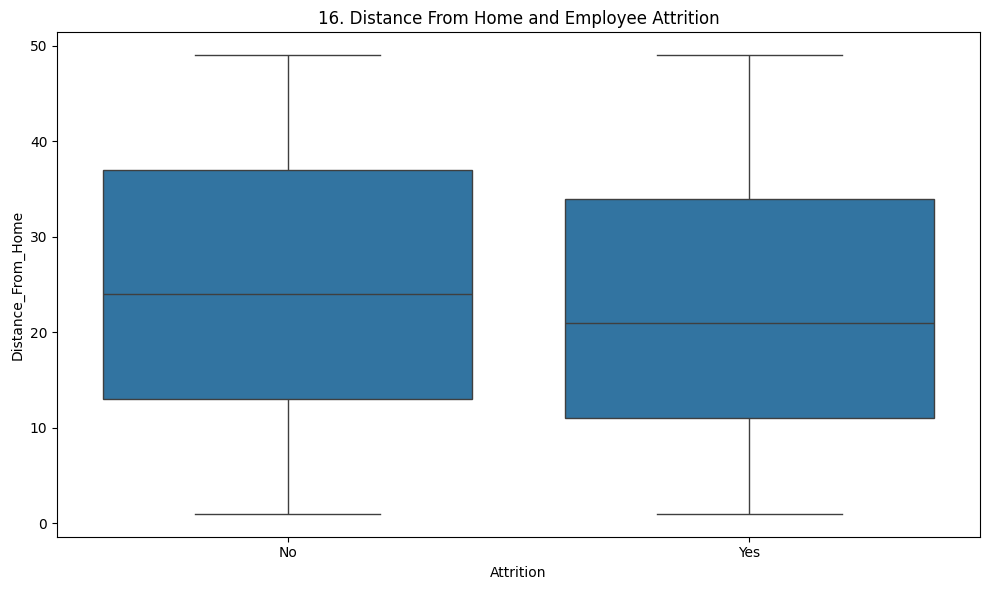

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='Distance_From_Home')
plt.title(f'{plot_no}. Distance From Home and Employee Attrition')
show_fig()
plot_no += 1

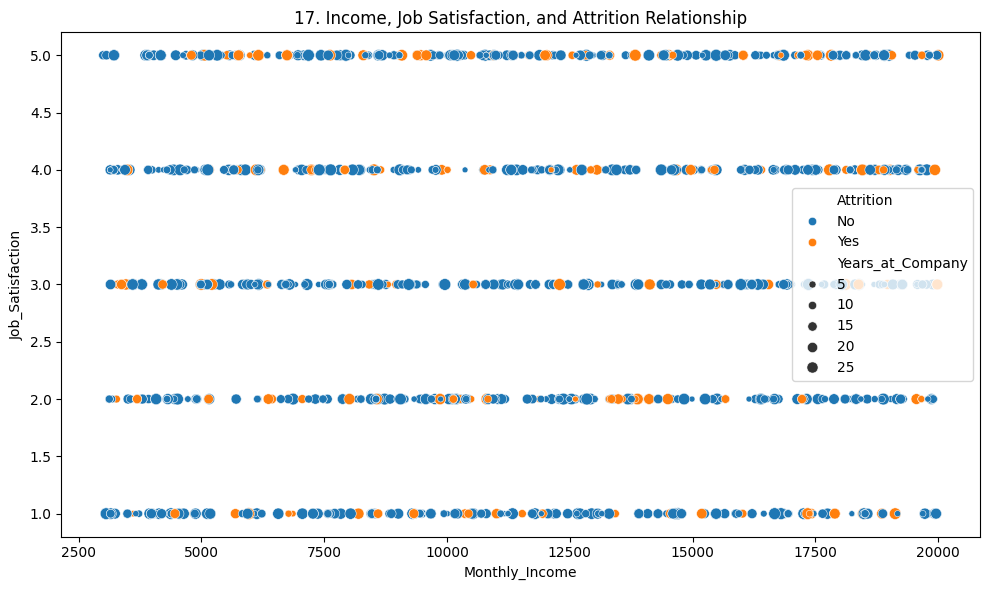

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Monthly_Income', y='Job_Satisfaction', hue='Attrition', size='Years_at_Company')
plt.title(f'{plot_no}. Income, Job Satisfaction, and Attrition Relationship')
show_fig()
plot_no += 1

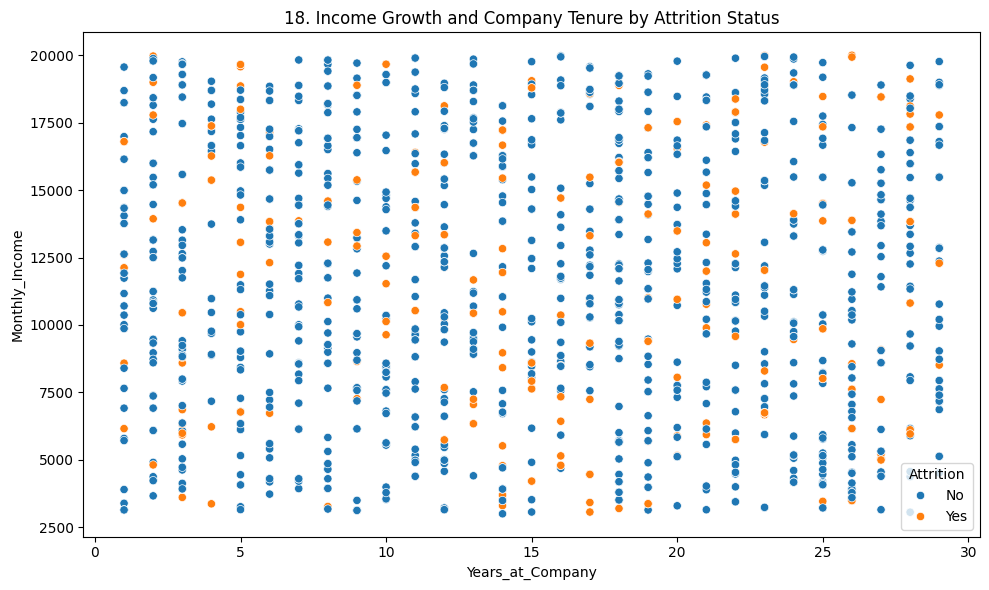

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Years_at_Company', y='Monthly_Income', hue='Attrition')
plt.title(f'{plot_no}. Income Growth and Company Tenure by Attrition Status')
show_fig()
plot_no += 1

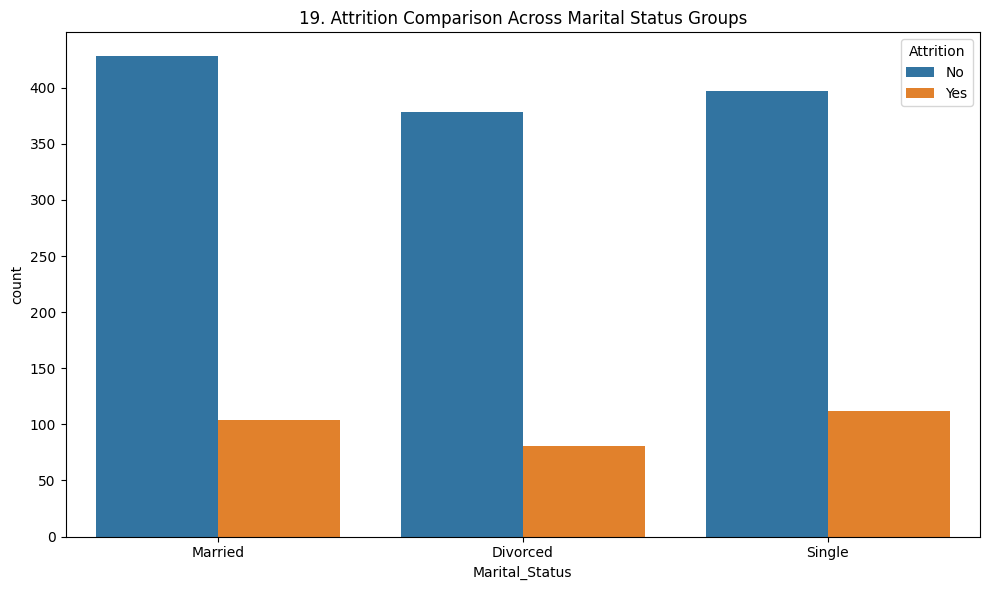

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Marital_Status', hue='Attrition')
plt.title(f'{plot_no}. Attrition Comparison Across Marital Status Groups')
show_fig()
plot_no += 1

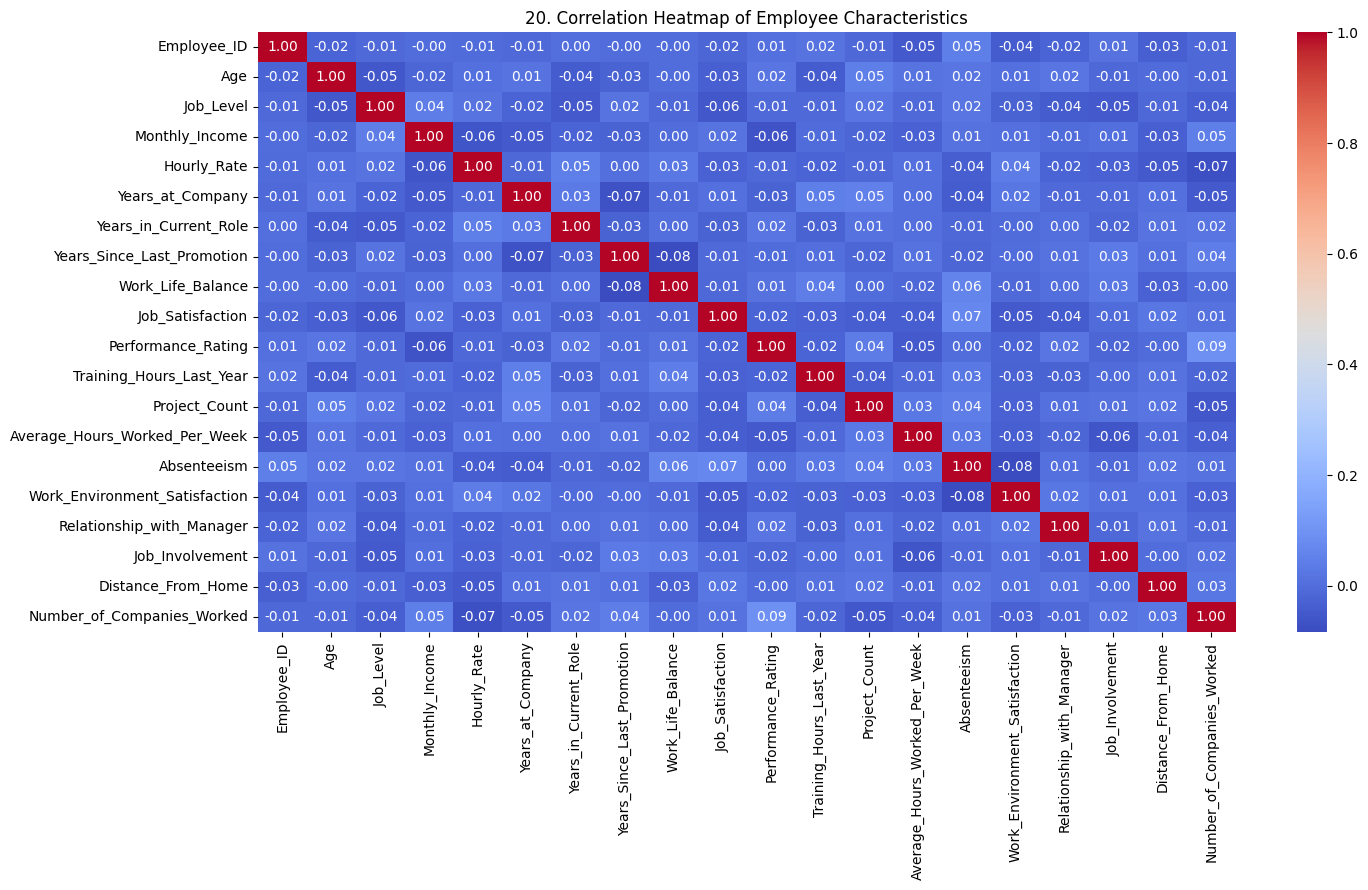

In [32]:
fig = plt.figure(figsize=(15, 9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Employee Characteristics')
show_fig()
plot_no += 1

# Model Training

## Separate features and target

In [33]:
X = df.drop(columns=['Attrition', 'Employee_ID'])
y = df['Attrition'].map({'No': 0, 'Yes': 1})

## Identify categorical and numerical columns

In [34]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

## Prepare numerical features

In [35]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Prepare categorical features

In [36]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

## Combine preprocessing steps

In [37]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

## Split dataset

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Create regularized gradient boosting model

In [39]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=15,
        min_samples_leaf=20,
        l2_regularization=2.0,
        random_state=42
    ))
])

## Train model

In [40]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company',
       'Years_in_Current_Role', 'Years_Since_Last_Promotion',
       'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating',...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime'], dtype='object'))])),
                ('classifier',
                 HistGradientBoostingClassifier(l2_regularization=2.0,
                                                learning_rate=0.05,
                                                max_iter=300, max_leaf_nodes=15,
                                                random_state=42))])

## Generate predictions

In [41]:
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

## Calculate training and testing accuracy

In [42]:
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Testing Accuracy: {test_accuracy:.2%}")

Testing Accuracy: 89.33%


## Print classification report

In [43]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Attrition', 'Attrition']
))


Classification Report:
              precision    recall  f1-score   support

No Attrition       0.89      1.00      0.94       241
   Attrition       0.97      0.47      0.64        59

    accuracy                           0.89       300
   macro avg       0.93      0.74      0.79       300
weighted avg       0.90      0.89      0.88       300



## Plot confusion matrix

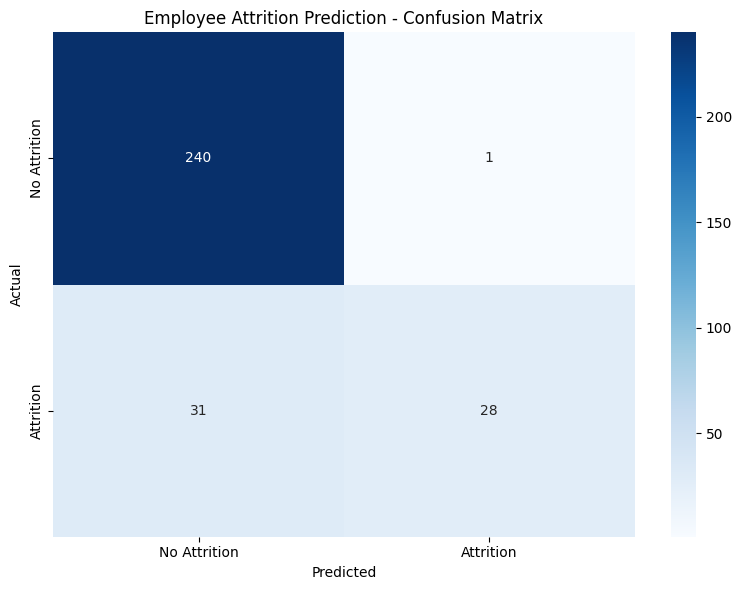

In [44]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Attrition', 'Attrition'],
    yticklabels=['No Attrition', 'Attrition']
)
plt.title('Employee Attrition Prediction - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()